In [30]:
# If you are running in a fresh environment, uncomment to install dependencies:
# !pip -q install torch torchvision matplotlib tqdm scikit-learn

import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torchvision import models
from torch.utils.data import DataLoader, random_split
import kagglehub

# kagglehub.login()


print("torch:", torch.__version__)

device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
print(f"Using {device} device")


def set_seed(seed: int = 42):
    """Make results as reproducible as possible across runs."""
    import os, random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)
    # If you later switch to CUDA and want maximal determinism:
    # os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)


set_seed(42)


torch: 2.11.0
Using cuda device


## 1. Dataset and DataLoader (15 pts)

In [31]:
from collections import defaultdict


# sci-kit learn stratified split to ensure each split has images from all folders
def stratified_split(targets, fraction, seed=42):
    rng = random.Random(seed)
    by_label = defaultdict(list)
    for idx, label in enumerate(targets):
        by_label[label].append(idx)
    first, second = [], []
    for label, indices in by_label.items():
        indices = indices[:]
        rng.shuffle(indices)
        n = round(len(indices) * fraction)
        first.extend(indices[:n])
        second.extend(indices[n:])
    return first, second

In [32]:
# Build the data pipeline

# base path to data downloaded through kagglehub
base = kagglehub.competition_download("ucsc-cse-144-spring-2026-final-project")
train_dir = os.path.join(base, "train")
test_dir = os.path.join(base, "test")


batch_size = 128
num_workers = 0  # For fully reproducible ordering across platforms

# NEW
train_tf = transforms.Compose(
    [
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

val_tf = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)


train_base = datasets.ImageFolder(root=train_dir, transform=train_tf)
val_base = datasets.ImageFolder(root=train_dir, transform=val_tf)

# using stratified split to ensure images from all folders in each split
train_idx, val_idx = stratified_split(train_base.targets, fraction=0.8)
train_set = torch.utils.data.Subset(train_base, train_idx)
val_set = torch.utils.data.Subset(val_base, val_idx)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

print("train/val:", len(train_set), len(val_set))

# print(train_set.class_to_idx)
idx_to_class = {v: k for k, v in train_base.class_to_idx.items()}
# print(idx_to_class)

# test_set = datasets.MNIST(
#     root=data_dir, train=False, transform=test_tf, target_transform=None, download=True
# )


# train_set, val_set = random_split(dataset=full_train, lengths=[800, 200])
# train_loader = DataLoader(dataset=train_set, batch_size=batch_size, shuffle=True)
# val_loader = DataLoader(dataset=val_set, batch_size=batch_size, shuffle=False)
# test_loader = DataLoader(
#     dataset=test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers
# )


# ========== YOUR CODE ENDS HERE ============

# print("train/val/test:", len(train_set), len(val_set), len(test_set))

train/val: 868 211


## 2. Define the CNN Model (20 pts)

In [33]:
class ResNet50(nn.Module):
    def __init__(self):
        super().__init__()
        self.transform = torchvision.models.ResNet50_Weights.IMAGENET1K_V2.transforms()
        self.resnet = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)
        self.parameters = [p.setValue(requires_grad=False) for p in model.parameters()]
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, out_features=100)
        
    def forward(self, x):
        x = self.resnet(x)
        return x

# model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# # freeze model weights
# for p in model.parameters():
#     p.requires_grad = False
# model.fc = nn.Linear(model.fc.in_features, 100)
# model = model.to(device)

## 3. Training Loop (40 pts)

### 3.1 Training Function (15 pts)

In [34]:
# Q3.1: Training function
criterion = nn.CrossEntropyLoss()

# only run for unfrozen weights
optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=1e-3
)


def train_one_epoch(model, loader):
    """Train for one epoch and return (avg_loss, accuracy)."""
    # ========== YOUR CODE STARTS HERE ==========
    # TODO:
    # - Set model to training mode
    # - Loop through batches in the loader
    # - For each batch:
    #   * Zero gradients
    #   * Forward pass
    #   * Compute loss
    #   * Backward pass
    #   * Optimizer step
    # - Track total loss and accuracy (IMPORTANT: get predicted labels and compare with targets)
    # - Return average loss and accuracy
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    model.train()
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        # NOTE: if necessary, change to model.zero_grad() but there should be only one optimizer
        # zero gradients
        optimizer.zero_grad()

        # forward pass
        # logits outputted by cross entropy loss
        # cross entropy -> log softmax -> negative log likelihood loss
        outputs = model(images)
        # compute losss
        loss = criterion(outputs, labels)

        # backward pass
        loss.backward()
        # optimizer step
        optimizer.step()

        running_loss += loss.item()
        predicted_classes = torch.argmax(outputs, dim=1)

        # for predicted_class, label in zip(predicted_classes, labels):
        #     correct_predictions += is_equal(predicted_class, label)

        # instead of the above code, vectorize the above operation
        correct_predictions += (predicted_classes == labels).sum().item()

        total_samples += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct_predictions / total_samples

    return (avg_loss, accuracy)
    # ========== YOUR CODE ENDS HERE ============

### 3.2 Validation Function (8 pts)

In [35]:
# Q3.2: Validation function
@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""
    # ========== YOUR CODE STARTS HERE ==========
    # TODO:
    # - Set model to evaluation mode
    # - Loop through batches without computing gradients
    # - Compute loss and accuracy
    # - Return average loss and accuracy
    running_loss = 0.0
    total_samples = 0
    correct_predictions = 0
    model.eval()
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        predicted_classes = torch.argmax(outputs, dim=1)

        # for predicted_class, label in zip(predicted_classes, labels):
        #     correct_predictions += is_equal(predicted_class, label)

        # instead of the above code, vectorize the above operation with pytorch tensor operations
        correct_predictions += (predicted_classes == labels).sum().item()

        total_samples += labels.size(0)
    avg_loss = running_loss / len(loader)
    accuracy = correct_predictions / total_samples

    return (avg_loss, accuracy)
    # ========== YOUR CODE ENDS HERE ============

### 3.3 Training Loop (11 pts)

In [36]:
# Q3.3: Training loop with checkpointing
epochs = 25
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "./checkpoints/best_mnist_cnn.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Loop through epochs
# - Each epoch: train, validate, log metrics
# - Track best validation accuracy and save checkpoint when improved
# - Print training and validation metrics each epoch
# - For checkpoint: save a dictionary containing keys `model_state_dict` and `epoch`

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch

        checkpoint = {"model_state_dict": model.state_dict(), "epoch": epoch}
        torch.save(checkpoint, ckpt_path)
        print("new best saved: {best_val_acc:.4f}")

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )


# ========== YOUR CODE ENDS HERE ============

print("Best val acc:", best_val_acc, "at epoch", best_epoch + 1)
print("Saved to:", ckpt_path)

new best saved: {best_val_acc:.4f}
Epoch 1/25 | Train Loss: 1.0688, Train Acc: 0.8018 | Val Loss: 1.5992, Val Acc: 0.5687


new best saved: {best_val_acc:.4f}
Epoch 2/25 | Train Loss: 0.9980, Train Acc: 0.8168 | Val Loss: 1.5899, Val Acc: 0.5829


Epoch 3/25 | Train Loss: 0.9331, Train Acc: 0.8410 | Val Loss: 1.5814, Val Acc: 0.5640


new best saved: {best_val_acc:.4f}
Epoch 4/25 | Train Loss: 0.9241, Train Acc: 0.8214 | Val Loss: 1.5512, Val Acc: 0.5877


Epoch 5/25 | Train Loss: 0.8677, Train Acc: 0.8456 | Val Loss: 1.5337, Val Acc: 0.5829


...

Epoch 21/25 | Train Loss: 0.6316, Train Acc: 0.8859 | Val Loss: 1.4246, Val Acc: 0.6209


new best saved: {best_val_acc:.4f}
Epoch 22/25 | Train Loss: 0.6283, Train Acc: 0.8836 | Val Loss: 1.4260, Val Acc: 0.6303


Epoch 23/25 | Train Loss: 0.5892, Train Acc: 0.9032 | Val Loss: 1.4175, Val Acc: 0.6209


Epoch 24/25 | Train Loss: 0.5747, Train Acc: 0.9078 | Val Loss: 1.4218, Val Acc: 0.6066


Epoch 25/25 | Train Loss: 0.5907, Train Acc: 0.8894 | Val Loss: 1.4163, Val Acc: 0.6066
Best val acc: 0.6303317535545023 at epoch 22
Saved to: ./checkpoints/best_mnist_cnn.pt


### 3.4 Plot Training Curves (6 pts)

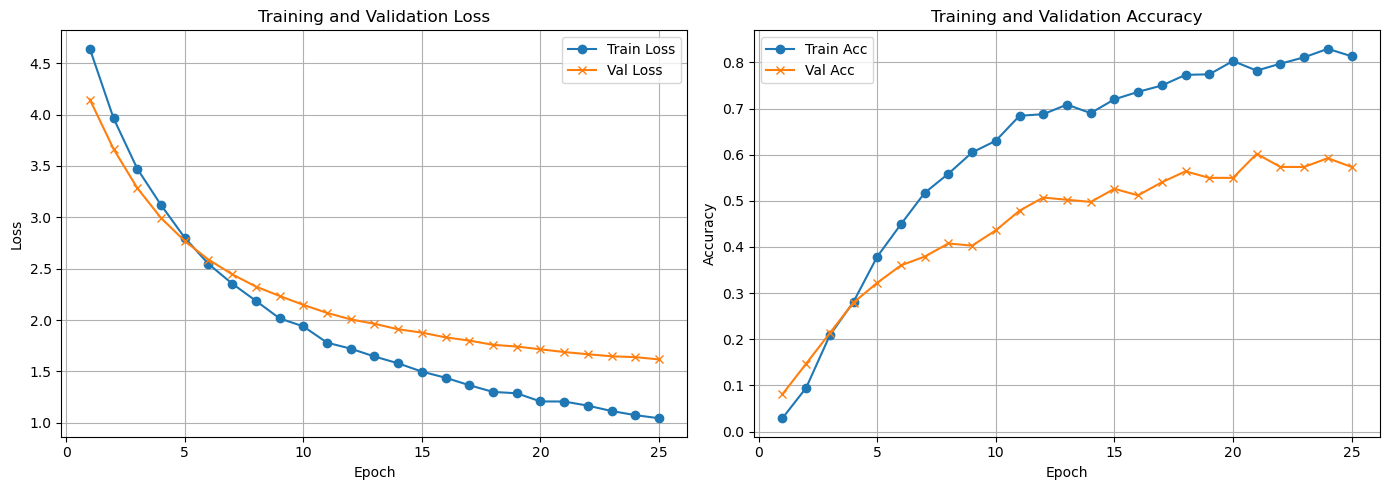

In [29]:
# Q3.4: Plot curves
# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Create two plots: one for loss (train vs val), one for accuracy (train vs val)
# - Use the history dictionary to get the values
# - Add labels, legends, and display the plots

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
plt.plot(epochs_range, history["val_loss"], label="Val Loss", marker="x")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc", marker="o")
plt.plot(epochs_range, history["val_acc"], label="Val Acc", marker="x")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ========== YOUR CODE ENDS HERE ============

## 4. Testing (5 pts)

In [10]:
idx_to_class = {v: k for k, v in train_set.class_to_idx.items()}

# # Q4: Test evaluation
# # ========== YOUR CODE STARTS HERE ==========
# # TODO:
# # - Load the best checkpoint (it's a dictionary with 'model_state_dict' and 'epoch')
# # - Load the model state from the checkpoint
# # - Evaluate on the test set
# # - Print test loss and accuracy

# checkpoint = torch.load(ckpt_path)

# model.load_state_dict(checkpoint["model_state_dict"])
# with torch.no_grad():
#     test_loss, test_acc = evaluate(model, test_loader)

# # ========== YOUR CODE ENDS HERE ============

# print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

AttributeError: 'Subset' object has no attribute 'class_to_idx'